In [648]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import random
%matplotlib inline

In [649]:
class Value:
  """
  @brief A scalar value node used in an automatic differentiation computational graph.

  Each Value object stores:
  - A scalar data value
  - The gradient of some final output with respect to this value
  - References to previous nodes used to compute it

  This enables reverse-mode automatic differentiation (backpropagation).
  """

  def __init__(self, data, _children=(), _op='', label=''):
    """
    @brief Construct a Value node.

    @param data      The scalar numeric value.
    @param _children Tuple of Value nodes used to compute this value.
    @param _op       String describing the operation that produced this node.
    @param label     Optional label for visualization/debugging.
    """

    ## Stored scalar value
    self.data = data

    ## Gradient of output with respect to this value
    self.grad = 0.0

    ## Function used during backpropagation
    self._backward = lambda: None

    ## Set of parent nodes in the computational graph
    self._prev = set(_children)

    ## Operation that produced this node (for graph visualization)
    self._op = _op

    ## Optional label
    self.label = label

  def __repr__(self):
    """
    @brief String representation of the Value object.

    @return String showing the stored scalar value.
    """
    return str(round(self.data,2))


  def __add__(self, other):
    """
    @brief Addition operator overload.

    Builds a new computational graph node representing:
        out = self + other

    @param other Value or scalar to add.
    @return Value node representing the result.
    """

    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      # d(out)/d(self) = 1
      self.grad += 1.0 * out.grad

      # d(out)/d(other) = 1
      other.grad += 1.0 * out.grad

    out._backward = _backward
    return out


  def __mul__(self, other):
    """
    @brief Multiplication operator overload.

    Builds a computational graph node representing:
        out = self * other

    @param other Value or scalar to multiply.
    @return Value node representing the result.
    """

    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      # Product rule derivatives
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad

    out._backward = _backward
    return out


  def __pow__(self, other):
    """
    @brief Power operator overload.

    Computes:
        out = self ** other

    @param other Exponent (must be int or float).
    @return Value node representing the result.
    """

    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        # d/dx (x^n) = n*x^(n-1)
        self.grad += other * (self.data ** (other - 1)) * out.grad

    out._backward = _backward
    return out


  def __rmul__(self, other):
    """
    @brief Right multiplication overload.

    Enables expressions like:
        scalar * Value
    """
    return self * other


  def __truediv__(self, other):
    """
    @brief Division operator overload.

    Computes:
        self / other
    """
    return self * other**-1


  def __neg__(self):
    """
    @brief Unary negation operator.

    Computes:
        -self
    """
    return self * -1


  def __sub__(self, other):
    """
    @brief Subtraction operator overload.

    Computes:
        self - other
    """
    return self + (-other)


  def __radd__(self, other):
    """
    @brief Right addition overload.

    Enables expressions like:
        scalar + Value
    """
    return self + other

  def __abs__(self):
    """
    @brief Absolute value

    Enables expressions like:
        |value|
    """
    out = Value(abs(self.data),(self, ), 'abs')

    def _backward():
      # d/dx |x| = x for use in adderNet (an approximation)
      self.grad += np.clip(self.data,-1,1) * out.grad

    out._backward = _backward
    return out


  def tanh(self):
    """
    @brief Hyperbolic tangent activation function.

    Computes:
        tanh(x)

    @return Value node representing tanh(self).
    """

    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      # d/dx tanh(x) = 1 - tanh(x)^2
      self.grad += (1 - t**2) * out.grad

    out._backward = _backward
    return out


  def exp(self):
    """
    @brief Exponential function.

    Computes:
        e^x

    @return Value node representing exp(self).
    """

    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      # d/dx e^x = e^x
      self.grad += out.data * out.grad

    out._backward = _backward
    return out


  def backward(self):
    """
    @brief Perform reverse-mode automatic differentiation.

    Computes gradients of all nodes in the computational graph
    with respect to this Value (assumed to be the output node).

    Steps:
    1. Build a topologically sorted list of nodes.
    2. Initialize output gradient to 1.
    3. Traverse graph in reverse order calling each node's
       stored backward function.
    """

    topo = []
    visited = set()

    def build_topo(v):
      """
      @brief Recursively build a topological ordering of the graph.
      """
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)

    build_topo(self)

    # Seed gradient
    self.grad = 1.0

    # Backpropagate
    for node in reversed(topo):
      node._backward()

  @staticmethod
  def mean(listOfValue):
    return np.sum(listOfValue) / len(listOfValue)

  @staticmethod
  def std(listOfValue):
    assert len(listOfValue) != 1
    mean = Value.mean(listOfValue)
    return (np.sum([(x-mean)**2 for x in listOfValue])/(len(listOfValue) - 1))**0.5

In [650]:
class Neuron:
    def __init__(self,inputColumns):
        # TODO:
        # weights
        self.w = [Value(random.uniform(-1,1),label=f"w{i}") for i in range(inputColumns)]

        # normalization
        self.gamma = Value(random.uniform(-1,1),label="gamma")
        self.beta = Value(random.uniform(-1,1),label="beta")

    # input is a 2d numpy array of Value objects
    def __call__(self,input):
        outs = []
        # for each row in input perform absolute difference
        for row in input:
            outs.append(-1*np.sum([a + -1*b for a, b in zip(row, self.w)]))

        # normalize outs
        mean = Value.mean(outs)
        std = Value.std(outs)

        outs = [((x - mean) / std) * self.gamma + self.beta for x in outs]

        return np.array(outs)

    def parameters(self):
      """
      @brief Return all learnable parameters of the neuron.

      This is useful during training when updating weights
      using gradient descent.

      @return List containing weights and bias.
      """

      return self.w + [self.gamma] + [self.beta]

In [651]:
class Layer:
  def __init__(self,inputColumns,n_neurons):
    self.neurons = [Neuron(inputColumns) for _ in range(n_neurons)]

  def __call__(self,input):
    # print(input.shape)
    cols = []
    for neuron in self.neurons:
      cols.append(neuron(input))

    return np.column_stack(cols)

  def parameters(self):
    """
    @brief Return all learnable parameters in the layer.

    Collects the parameters from every neuron in the layer.

    @return List of Value objects representing weights and biases.
    """

    return [p for neuron in self.neurons for p in neuron.parameters()]


In [652]:
class MLP:
  def __init__(self,nin,nout):
    # nin is number of input features = number of columns
    # nout is a list of the number of neurons in each layer

    sz = [nin] + nout

    ## Create the sequence of layers
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nout))]

  def __call__(self, x):
      for layer in self.layers:
        x = layer(x)
      return x

  def parameters(self):
      """
      @brief Return all learnable parameters in the network.

      This collects parameters from every layer, which in turn
      collects parameters from each neuron.

      @return List of Value objects representing all weights and biases.
      """

      return [p for layer in self.layers for p in layer.parameters()]


In [655]:
nn = MLP(2, [3,1])

input = np.array([[1,2], [3,4], [5,6]])

expected = np.array([row[0]**2+row[1]**2 for row in input])
print(expected)

output = nn(input).flatten()

print(output)

[ 5 25 61]
[-0.56 -0.52 -0.48]


In [656]:
loss_track = []
for k in range(3000):

  # forward pass
  ypred = nn(input).flatten()
  loss = sum((yout - ygt)**2 for ygt, yout in zip(expected, ypred))

  # backward pass
  for p in nn.parameters():
    p.grad = 0.0
  loss.backward()

  # update
  for p in nn.parameters():
    p.data += -0.02 * p.grad

  loss_track.append([k,loss.data])
  #print(k, loss.data)

print(nn(input).flatten())

[2.33 30.33 58.33]


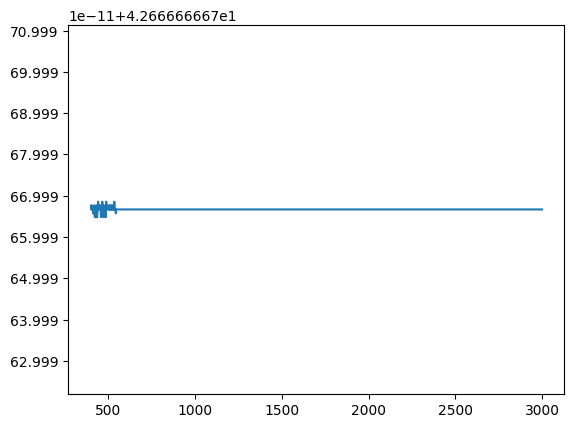

In [659]:
plt.plot([x[0] for x in loss_track[400:]], [x[1] for x in loss_track[400:]])